In [1]:
# system libraries
import sys
import os
import re
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

# visualisation libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from jinja2 import Template

# data cleaning functions
from data_processing import load_and_clean_survey_data

df = load_and_clean_survey_data('../data/raw/GiG2025_clean.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   first_name                 55 non-null     object
 1   last_name                  55 non-null     object
 2   email_id                   55 non-null     object
 3   academic_position          55 non-null     object
 4   faculty                    55 non-null     object
 5   department                 55 non-null     object
 6   discipline                 55 non-null     object
 7   health_research_keywords   55 non-null     object
 8   research_methods           53 non-null     object
 9   research_methods_other     54 non-null     object
 10  research_methods_keywords  55 non-null     object
 11  health_research_pubs       54 non-null     object
 12  research_methods_pubs      39 non-null     object
 13  third_party_funding_org    51 non-null     object
 14  collab_count

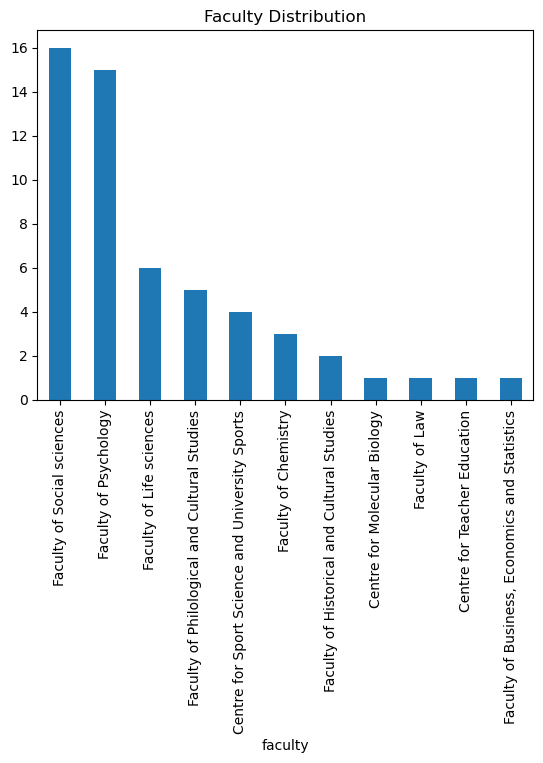

In [3]:
df['faculty'].value_counts().plot(kind='bar')
plt.title('Faculty Distribution')
plt.show()

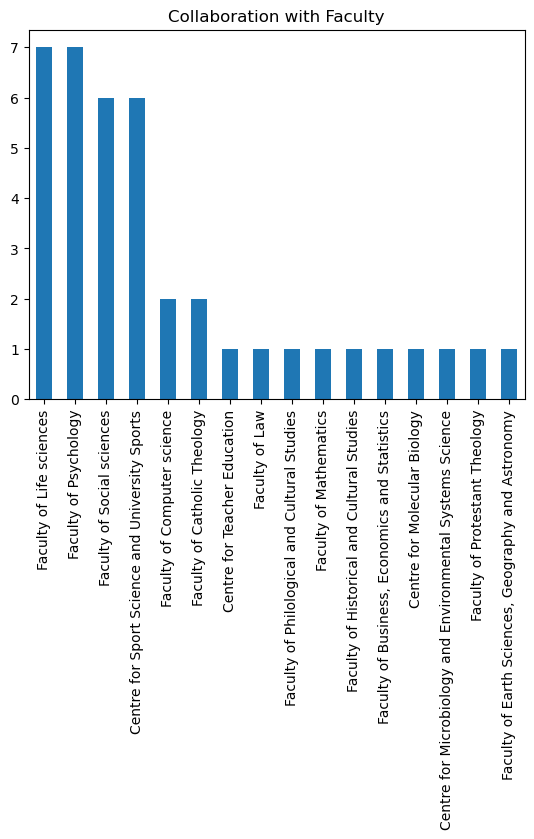

In [4]:
collab_fac_combined = pd.concat([df['collab_fac1'], df['collab_fac2'], df['collab_fac3']])
collab_fac_combined = collab_fac_combined.dropna()
collab_fac_combined.value_counts().plot(kind='bar')
plt.title('Collaboration with Faculty')
plt.show()

In [5]:
# ideas for alluvial plot:
# faculty -> combined collab fac 1 and 2
# for more ideas, examine the categorical variables in the survey data

In [6]:
# Prepare data for Sankey diagram
faculty = df['faculty'].dropna().tolist()
collab_fac1 = df['collab_fac1'].dropna().tolist()
# collab_fac2 = df['collab_fac2'].dropna().tolist()

# Combine all nodes
all_nodes = list(set(faculty + collab_fac1))

# Create a mapping from node name to index
node_indices = {node: idx for idx, node in enumerate(all_nodes)}

# Create source and target indices for Sankey diagram
sources = [node_indices[fac] for fac in faculty if fac in node_indices]
targets1 = [node_indices[collab] for collab in collab_fac1 if collab in node_indices]
# targets2 = [node_indices[collab] for collab in collab_fac2 if collab in node_indices]

# Combine sources and targets
sources_combined = sources + sources
targets_combined = targets1

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=sources_combined,
        target=targets_combined,
        value=[1] * len(targets_combined)  # set all values to 1 for simplicity
    )
)])

fig.update_layout(title_text="Collaborations Among the Faculty @ the Health Research Network", font_size=13)
fig.show()

In [7]:
# Prepare data for Sankey diagram with research methods
faculty = df['faculty'].dropna().tolist()
research_methods = df['research_methods'].dropna().tolist()

# Combine all nodes
all_nodes = list(set(faculty + research_methods))

# Create a mapping from node name to index
node_indices = {node: idx for idx, node in enumerate(all_nodes)}

# Create source and target indices for Sankey diagram
sources = [node_indices[fac] for fac in faculty if fac in node_indices]
targets = [node_indices[method] for method in research_methods if method in node_indices]

# Create the Sankey diagram
fig_sankey_rm = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=sources,
        target=targets,
        value=[1] * len(targets)  # set all values to 1 for simplicity
    )
)])

fig_sankey_rm.update_layout(title_text="Research Methods Used by the Faculty", font_size=13)
fig_sankey_rm.show()

In [8]:
df.columns

Index(['first_name', 'last_name', 'email_id', 'academic_position', 'faculty',
       'department', 'discipline', 'health_research_keywords',
       'research_methods', 'research_methods_other',
       'research_methods_keywords', 'health_research_pubs',
       'research_methods_pubs', 'third_party_funding_org', 'collab_countries',
       'health_third_mission', 'participate_in_kinderuni',
       'participate_in_lndf', 'outreach_other', 'collab_fac1', 'collab_fac2',
       'collab_fac3', 'collab_uni1', 'collab_uni2', 'collab_uni3',
       'collab_uni4', 'collab_uni5', 'collab_uni6', 'collab_uni7',
       'collab_uni8', 'collab_uni9', 'collab_uni10', 'collab_uni11'],
      dtype='object')

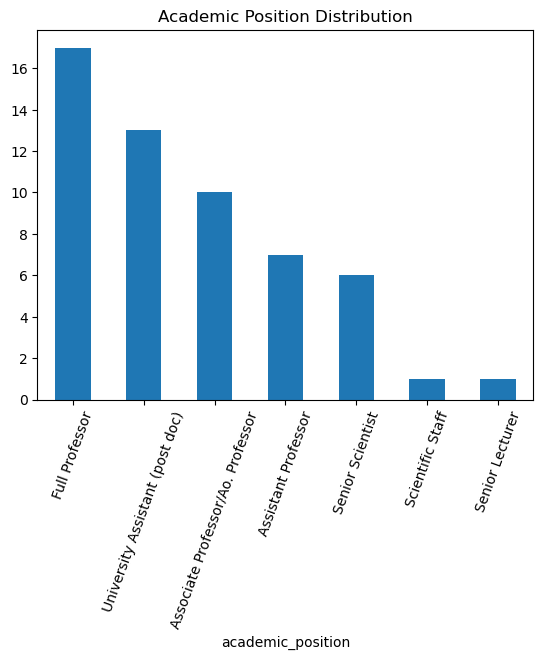

In [9]:
df['academic_position'].value_counts().plot(kind='bar')
plt.title('Academic Position Distribution')
plt.xticks(rotation=70)
plt.show()

In [10]:
df.columns

Index(['first_name', 'last_name', 'email_id', 'academic_position', 'faculty',
       'department', 'discipline', 'health_research_keywords',
       'research_methods', 'research_methods_other',
       'research_methods_keywords', 'health_research_pubs',
       'research_methods_pubs', 'third_party_funding_org', 'collab_countries',
       'health_third_mission', 'participate_in_kinderuni',
       'participate_in_lndf', 'outreach_other', 'collab_fac1', 'collab_fac2',
       'collab_fac3', 'collab_uni1', 'collab_uni2', 'collab_uni3',
       'collab_uni4', 'collab_uni5', 'collab_uni6', 'collab_uni7',
       'collab_uni8', 'collab_uni9', 'collab_uni10', 'collab_uni11'],
      dtype='object')

In [11]:
# Replace 'sigmund freud uni, vienna' with 'Sigmund Freud University Vienna' in specified columns
for col in ['collab_uni1', 'collab_uni2', 'collab_uni3', 'collab_uni4', 'collab_uni5', 'collab_uni6', 'collab_uni7', 'collab_uni8', 'collab_uni9', 'collab_uni10', 'collab_uni11']:
    df[col] = df[col].replace('sigmund freud uni, vienna', 'Sigmund Freud University Vienna')

In [12]:
# Prepare data for Sankey diagram with faculty and collab_univ
faculty = df['faculty'].dropna().tolist()

# Concatenate all collab_uni columns
collab_univ = pd.concat([df[col] for col in df.columns if col.startswith('collab_uni')]).dropna().tolist()

# Combine all nodes
all_nodes = list(set(faculty + collab_univ))

# Create a mapping from node name to index
node_indices = {node: idx for idx, node in enumerate(all_nodes)}

# Create source and target indices for Sankey diagram
sources_faculty_to_collab_univ = [node_indices[fac] for fac in faculty if fac in node_indices]
targets_faculty_to_collab_univ = [node_indices[uni] for uni in collab_univ if uni in node_indices]

# Combine sources and targets
sources_combined = sources_faculty_to_collab_univ
targets_combined = targets_faculty_to_collab_univ

# Create the Sankey diagram
fig_sankey_austria = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=sources_combined,
        target=targets_combined,
        value=[1] * len(targets_combined)  # set all values to 1 for simplicity
    )
)])

fig_sankey_austria.update_layout(font_size=12)
fig_sankey_austria.show()

In [13]:
df.head()

,first_name,last_name,email_id,academic_position,faculty,department,discipline,health_research_keywords,research_methods,research_methods_other,...,collab_uni2,collab_uni3,collab_uni4,collab_uni5,collab_uni6,collab_uni7,collab_uni8,collab_uni9,collab_uni10,collab_uni11
0,Giorgia,Silani,giorgia.silani@univie.ac.at,Associate Professor/Ao. Professor,Faculty of Psychology,Department of Clinical and Health Psychology,social neuroscience,"[mental health literacy, emotions, empathy, ne...",mainly quantitative,-99,...,University of Salzburg,None,None,None,None,None,None,None,None,None
1,Laura,König,laura.koenig@univie.ac.at,Full Professor,Faculty of Psychology,Department of Clinical and Health Psychology,Health psychology,"[health promotion, diet, physical activity, se...",mainly quantitative,-99,...,University of Music and Performing Arts in Vienna,None,None,None,None,None,None,None,None,None
2,Julia,Holzer,julia.holzer@univie.ac.at,Scientific Staff,Faculty of Psychology,Department of Developmental and Educational Ps...,Psychology,"[well-being, motivation, basic psychological n...",both quantitative and qualitative,-99,...,None,None,None,None,None,None,None,None,None,None
3,Martina,Zemp,martina.zemp@univie.ac.at,Full Professor,Faculty of Psychology,Department of Clinical and Health Psychology,Clinical Child and Adolescent Psychology,"[children, adolescents, families, couples, rel...",mainly quantitative,-99,...,None,None,None,None,None,None,None,None,None,None
4,Valeria,Bordone,valeria.bordone@univie.ac.at,Associate Professor/Ao. Professor,Faculty of Social sciences,Department of Sociology,Sociology,"[Cognition, wellbeing, intergenerational relat...",mainly quantitative,-99,...,None,None,None,None,None,None,None,None,None,None


In [14]:
collab_institutes_dict = {
    'Argentina': 'Argentina',
    'Australia': 'Australia',
    'Belgium': 'Belgium',
    'Brazil': 'Brazil',
    'Canada': 'Canada',
    'Center for global health policy': 'USA',
    'China': 'China',
    'Czech Republic': 'Czech Republic',
    'Denmark': 'Denmark',
    'France': 'France',
    'Germany': 'Germany',
    'Hungary': 'Hungary',
    'Icahn School of Medicine at Mount Sinai': 'USA',
    'Institute of International Relations Prague': 'Czech Republic',
    'Israel': 'Israel',
    'Italy': 'Italy',
    'Japan': 'Japan',
    'KU Leuven': 'Belgium',
    'KU Leuven (Belgium)': 'Belgium',
    'Kosovo': 'Kosovo',
    'LMU Munich': 'Germany',
    'Latvia': 'Latvia',
    'Netherlands': 'Netherlands',
    'New Zealand': 'New Zealand',
    'Norway': 'Norway',
    'Nottingham Trent University': 'UK',
    'PFH G√∂ttingen': 'Germany',
    'Romenia': 'Romania',
    'Serbia': 'Serbia',
    'Slovak Academy of Science': 'Slovakia',
    'Slovakia': 'Slovakia',
    'Spain': 'Spain',
    'Sports Medicine University of Saaarland': 'Germany',
    'Sports medicine TU Munich': 'Germany',
    'Sweden': 'Sweden',
    'Switzerland': 'Switzerland',
    'Turkey (PIs of two large': 'Turkey',
    'UCL': 'UK',
    'UK': 'UK',
    'UK (Oxford)': 'UK',
    'US': 'USA',
    'USA': 'USA',
    'USI Switzerland': 'Switzerland',
    'Ukraine': 'Ukraine',
    'Universitat Pompeu Fabra': 'Spain',
    'University of Ghana': 'Ghana',
    'University of Padua': 'Italy',
    'University of Pennsylvania': 'USA',
    'University of Sussex': 'UK',
    'Yale School of Medicine': 'USA',
    'ZEMKI Bremen': 'Germany',
    'multi-national studies I contributed to and with whom I have ongoing collaborations)': 'Various',
    'the Netherlands': 'Netherlands',
    'EURO Working Group Operations Research Applied to Health Services': 'Various',
    'University of Luxembourg': 'Luxembourg',
    'Concordia University Montreal': 'Canada',
    'Universiteit van Amsterdam': 'Netherlands',
}
collab_institutes_dict

{'Argentina': 'Argentina',
 'Australia': 'Australia',
 'Belgium': 'Belgium',
 'Brazil': 'Brazil',
 'Canada': 'Canada',
 'Center for global health policy': 'USA',
 'China': 'China',
 'Czech Republic': 'Czech Republic',
 'Denmark': 'Denmark',
 'France': 'France',
 'Germany': 'Germany',
 'Hungary': 'Hungary',
 'Icahn School of Medicine at Mount Sinai': 'USA',
 'Institute of International Relations Prague': 'Czech Republic',
 'Israel': 'Israel',
 'Italy': 'Italy',
 'Japan': 'Japan',
 'KU Leuven': 'Belgium',
 'KU Leuven (Belgium)': 'Belgium',
 'Kosovo': 'Kosovo',
 'LMU Munich': 'Germany',
 'Latvia': 'Latvia',
 'Netherlands': 'Netherlands',
 'New Zealand': 'New Zealand',
 'Norway': 'Norway',
 'Nottingham Trent University': 'UK',
 'PFH G√∂ttingen': 'Germany',
 'Romenia': 'Romania',
 'Serbia': 'Serbia',
 'Slovak Academy of Science': 'Slovakia',
 'Slovakia': 'Slovakia',
 'Spain': 'Spain',
 'Sports Medicine University of Saaarland': 'Germany',
 'Sports medicine TU Munich': 'Germany',
 'Sweden': 

In [15]:
df['collab_countries_clean'] = df['collab_countries'].apply(lambda x: ', '.join([collab_institutes_dict.get(country.strip(), country.strip()) for country in re.split(r'[;,]', x)]) if pd.notna(x) else x)

In [16]:
df['collab_countries_clean'].head()

0                                                -99
1    USA, UK, Netherlands, Belgium, Germany, Ukraine
2                                                USA
3                                                -99
4                                 Italy, UK, Germany
Name: collab_countries_clean, dtype: object

In [17]:
df['collab_countries'].head()

0                                                  -99
1    USA, UK, the Netherlands, Belgium, Germany, Uk...
2              Icahn School of Medicine at Mount Sinai
3                                                  -99
4                                   Italy, UK, Germany
Name: collab_countries, dtype: object

In [18]:
# Create source-target pairs for each faculty-country combination
faculty_country_pairs = []
    
for _, row in df.iterrows():
    faculty = row['faculty']
    if pd.notna(row['collab_countries_clean']) and row['collab_countries_clean'] and row['collab_countries_clean'] not in ['-99', 'xx']:
        # Split countries if multiple exist
        countries = row['collab_countries_clean'].split(', ')
        for country in countries:
            if country.strip() and country != 'Various':  # Ensure non-empty country
                faculty_country_pairs.append((faculty, country.strip()))

# Create a DataFrame from these pairs for counting
pairs_df = pd.DataFrame(faculty_country_pairs, columns=['faculty', 'country'])
pair_counts = pairs_df.groupby(['faculty', 'country']).size().reset_index(name='count')

# Create nodes for faculties and countries (no duplicates)
unique_faculties = pairs_df['faculty'].unique()
unique_countries = pairs_df['country'].unique()

# Create node labels
node_labels = list(unique_faculties) + list(unique_countries)

# Create source and target indices
faculty_indices = {faculty: i for i, faculty in enumerate(unique_faculties)}
country_indices = {country: i + len(unique_faculties) for i, country in enumerate(unique_countries)}

# Create source, target, and value lists for the Sankey diagram
sources = [faculty_indices[row['faculty']] for _, row in pair_counts.iterrows()]
targets = [country_indices[row['country']] for _, row in pair_counts.iterrows()]
values = pair_counts['count'].tolist()

# Create Sankey diagram
fig_sankey_world = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig_sankey_world.update_layout(
    font_size=13,
    height=800
)

In [20]:
output_html_path=r"../data/processed/gig2025_visualisations_2.html"
input_template_path = r"../data/processed/plotly_template_2.html"

plotly_jinja_data = {
    "fig_sankey_austria": fig_sankey_austria.to_html(full_html=False),
    "fig_sankey_world": fig_sankey_world.to_html(full_html=False),
}

with open(output_html_path, "w", encoding="utf-8") as output_file:
    with open(input_template_path) as template_file:
        j2_template = Template(template_file.read())
        output_file.write(j2_template.render(plotly_jinja_data))